# Análise Estatística
## Análise de Dados de Compliance Pública - Tese de MBA

**Objetivo:** Realizar análise estatística rigorosa:
- Análise de correlação
- Testes de hipóteses
- Regressão linear múltipla
- Diagnósticos e validação do modelo

## Passo a passo (estilo aula)

1. Pacotes e configuração do ambiente
2. Reprodutibilidade
3. Carregamento dos dados
4. Blocos de análise
5. Resumo e interpretação


# Pacotes


In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro, normaltest, jarque_bera

from src.analysis.data_loader import GoldDataLoader

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
pd.set_option('display.float_format', '{:.4f}'.format)


In [2]:
import matplotlib as mpl
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = (-99, 99)


# Reprodutibilidade


In [3]:
import os
import random

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Semente de reprodutibilidade fixada em {SEED}")


Semente de reprodutibilidade fixada em 42


In [4]:
import json as _json

_rtcfg_path = os.path.join('..', 'config', 'runtime_config.json')
if os.path.exists(_rtcfg_path):
    with open(_rtcfg_path) as _f:
        _rtcfg = _json.load(_f)
else:
    _rtcfg = {}

S3_BUCKET_NAME = os.environ.get('S3_BUCKET_NAME', _rtcfg.get('aws', {}).get('s3_bucket_name', ''))
AWS_PROFILE = os.environ.get('AWS_PROFILE', _rtcfg.get('aws', {}).get('profile', None))


## 1. Carregar Dados

In [5]:
loader = GoldDataLoader(
    bucket_name=S3_BUCKET_NAME,
    aws_profile=AWS_PROFILE
)

df = loader.load_dataset('analysis_compliance')
print(f"Carregados {len(df)} observações (estados)")
df.head()


2026-04-08 19:22:19,178 - INFO - Found credentials in shared credentials file: ~/.aws/credentials
2026-04-08 19:22:19,234 - INFO - 📥 Loading analysis_compliance from S3: gold/analysis_compliance/data.parquet
2026-04-08 19:22:19,922 - INFO - ✅ Loaded 27 records, 20 columns


Carregados 27 observações (estados)


,state_code,state_name,region_code,region_name,n_municipalities,population,avg_literacy_rate,avg_income,n_sanctions,n_sanctions_ceis,n_sanctions_cnep,n_sanctions_cepim,sanctions_per_100k,log_population,log_income,is_norte,is_nordeste,is_sudeste,is_sul,is_centro_oeste
0,11,Rondônia,1,Norte,52,1581196,91.2900,1211.9600,499,496,3,0,31.5584,14.2737,7.1000,1,0,0,0,0
1,12,Acre,1,Norte,22,830018,83.4100,778.4900,115,115,0,0,13.8551,13.6292,6.6574,1,0,0,0,0
2,13,Amazonas,1,Norte,62,3941613,86.9600,625.4400,217,214,3,0,5.5054,15.1871,6.4385,1,0,0,0,0
3,14,Roraima,1,Norte,15,636707,86.7000,724.2000,125,125,0,0,19.6323,13.3641,6.5851,1,0,0,0,0
4,15,Pará,1,Norte,144,8120131,87.8400,764.4600,351,349,2,0,4.3226,15.9099,6.6392,1,0,0,0,0


## 2. Análise de Correlação

### 2.1 Pearson Matriz de Correlação

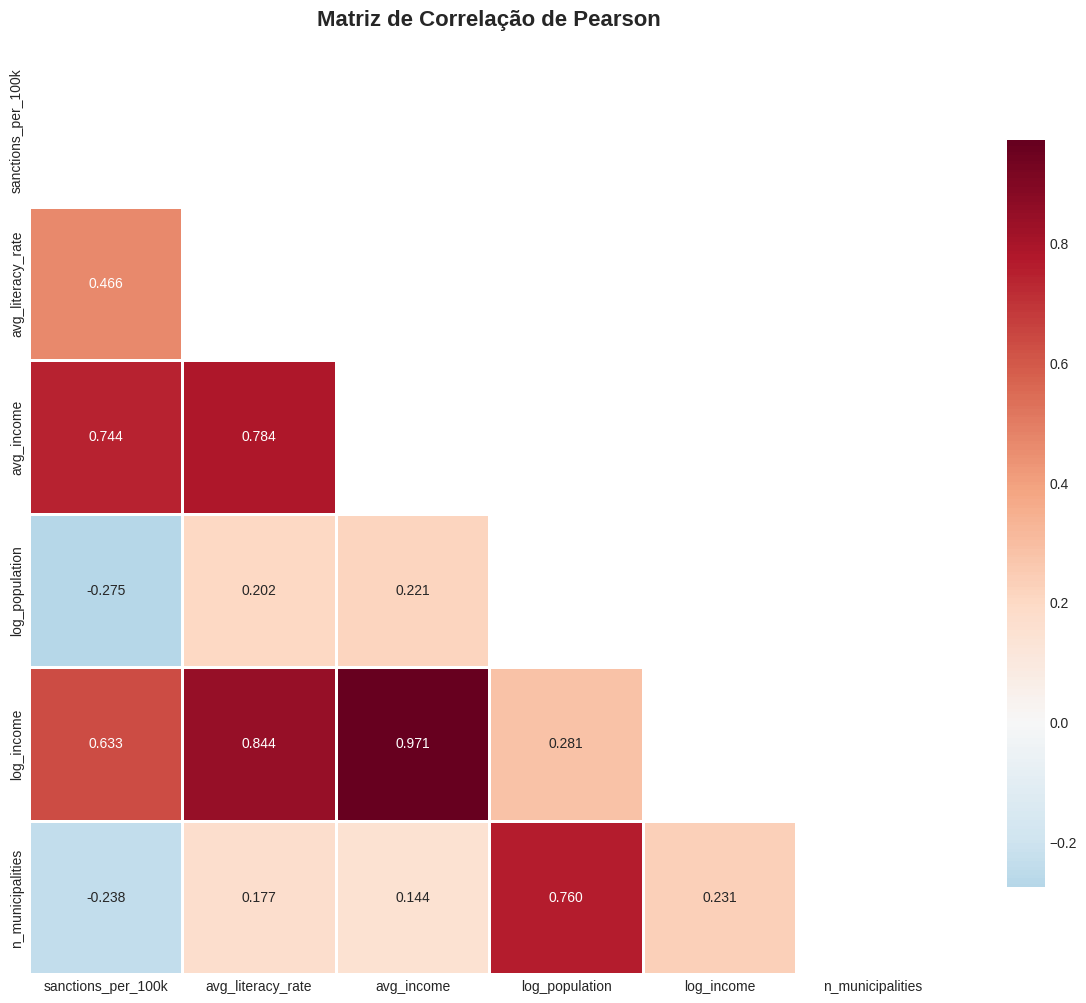


Correlações com Sanções por 100 mil:
sanctions_per_100k    1.0000
avg_income            0.7444
log_income            0.6329
avg_literacy_rate     0.4661
n_municipalities     -0.2382
log_population       -0.2754
Name: sanctions_per_100k, dtype: float64


In [6]:
key_vars = ['sanctions_per_100k', 'avg_literacy_rate', 'avg_income', 
            'log_population', 'log_income', 'n_municipalities']

corr_matrix = df[key_vars].corr(method='pearson')

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação de Pearson', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelações com Sanções por 100 mil:")
print("=" * 60)
sanctions_corr = corr_matrix['sanctions_per_100k'].sort_values(ascending=False)
print(sanctions_corr)


### 2.2 Teste de Significância Estatística

In [7]:
from scipy.stats import pearsonr

def correlation_test(x, y, var_names):
    """Calcula correlação de Pearson com valor-p."""
    clean_data = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(clean_data) < 3:
        return None, None
    r, p = pearsonr(clean_data['x'], clean_data['y'])
    return r, p

results = []
target = df['sanctions_per_100k']

for var in ['avg_literacy_rate', 'avg_income', 'log_income', 'log_population', 'n_municipalities']:
    r, p = correlation_test(target, df[var], (var, 'sanctions_per_100k'))
    if r is not None:
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        results.append({
            'Variável': var,
            'Correlação (r)': f"{r:.4f}",
            'Valor-p': f"{p:.4f}",
            'Significância': sig
        })

corr_results = pd.DataFrame(results)
print("\nTestes de Correlação com Sanções por 100 mil")
print("=" * 80)
print("Significância: *** p<0.001, ** p<0.01, * p<0.05, ns = não significativo")
print("=" * 80)
display(corr_results)



Testes de Correlação com Sanções por 100 mil
Significância: *** p<0.001, ** p<0.01, * p<0.05, ns = não significativo


,Variável,Correlação (r),Valor-p,Significância
0,avg_literacy_rate,0.4661,0.0143,*
1,avg_income,0.7444,0.0000,***
2,log_income,0.6329,0.0004,***
3,log_population,-0.2754,0.1644,ns
4,n_municipalities,-0.2382,0.2314,ns


### 2.3 Gráficos de Dispersão com Linhas de Regressão

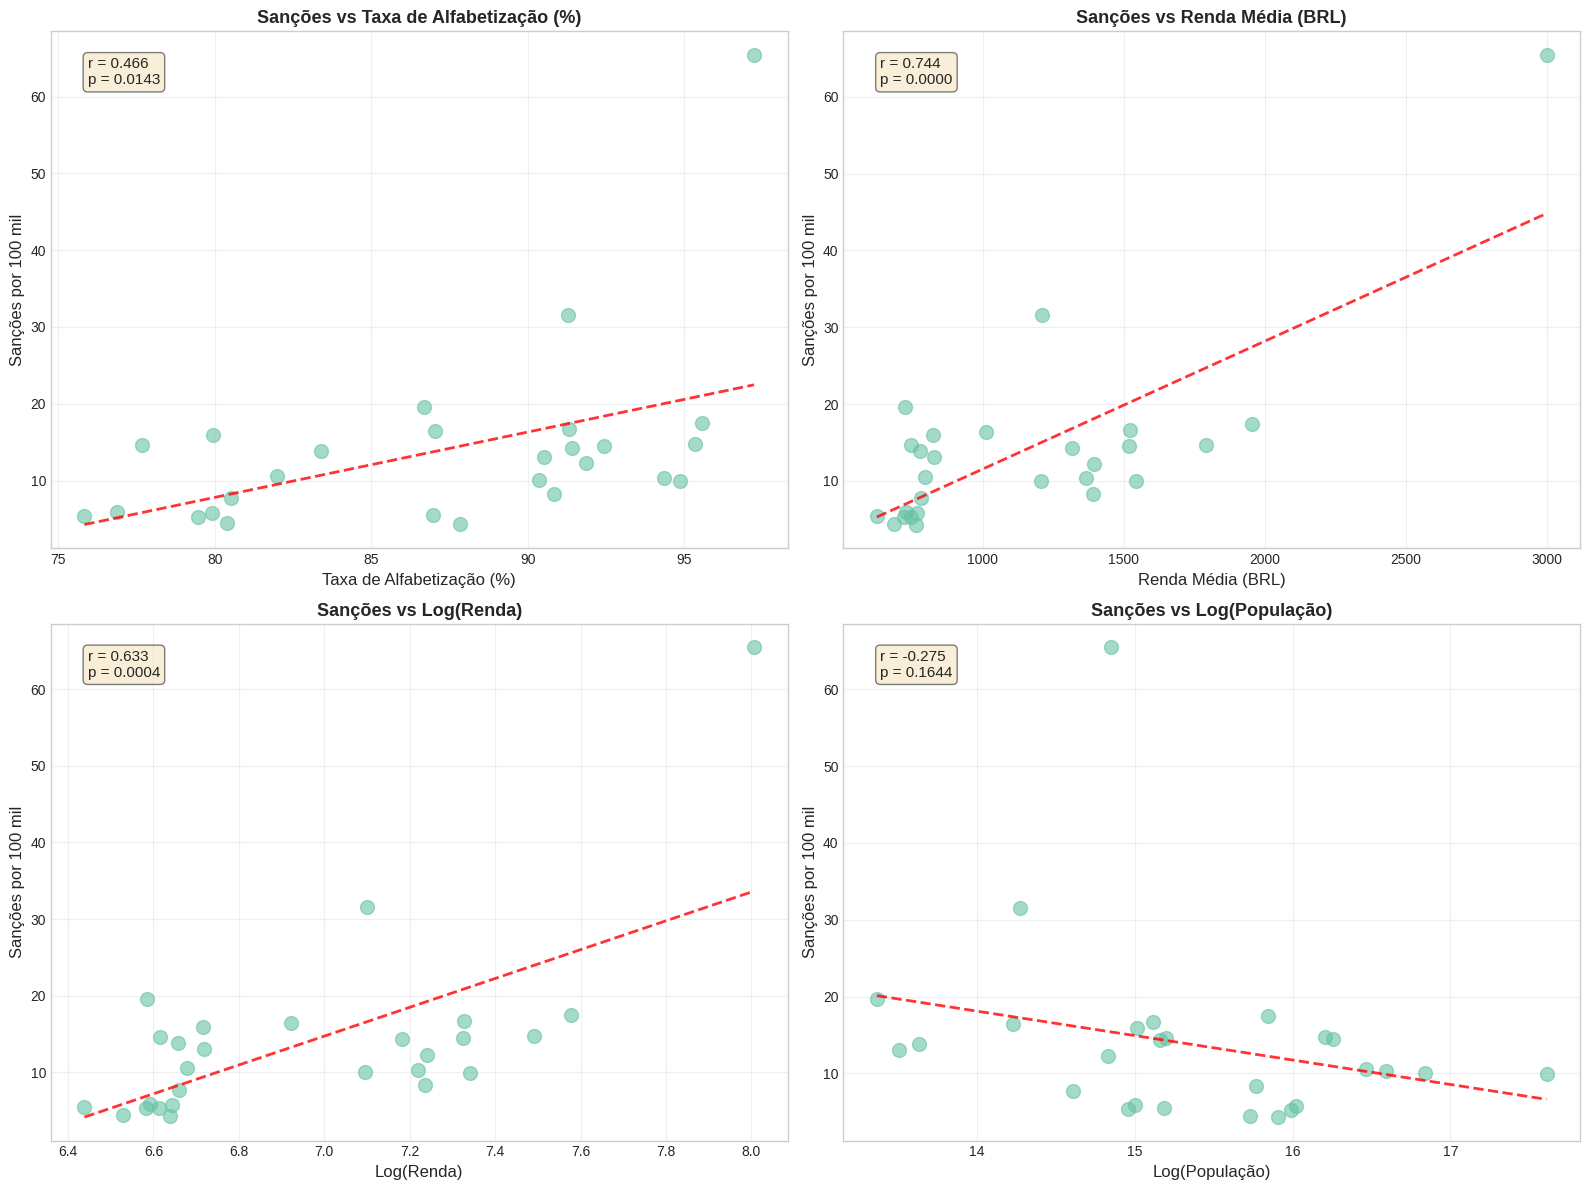

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

vars_to_plot = [
    ('avg_literacy_rate', 'Taxa de Alfabetização (%)', axes[0, 0]),
    ('avg_income', 'Renda Média (BRL)', axes[0, 1]),
    ('log_income', 'Log(Renda)', axes[1, 0]),
    ('log_population', 'Log(População)', axes[1, 1])
]

for var, label, ax in vars_to_plot:
    ax.scatter(df[var], df['sanctions_per_100k'], alpha=0.6, s=100)
    
    z = np.polyfit(df[var].dropna(), df['sanctions_per_100k'][df[var].notna()], 1)
    p = np.poly1d(z)
    ax.plot(df[var].sort_values(), p(df[var].sort_values()), "r--", alpha=0.8, linewidth=2)
    
    r, pval = correlation_test(df[var], df['sanctions_per_100k'], (var, 'sanctions'))
    ax.text(0.05, 0.95, f'r = {r:.3f}\np = {pval:.4f}', 
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Sanções por 100 mil', fontsize=12)
    ax.set_title(f'Sanções vs {label}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Testes de Hipótese

### 3.1 Diferenças Regionais (ANOVA)

In [9]:
from scipy.stats import f_oneway

regions = df['region_name'].unique()
groups = [df[df['region_name'] == region]['sanctions_per_100k'].dropna() for region in regions]

f_stat, p_value = f_oneway(*groups)

print("ANOVA One-Way: Diferenças Regionais em Sanções por 100 mil")
print("=" * 70)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nResultado: {'Significativo' if p_value < 0.05 else 'Não significativo'} diferenças regionais")
print("\nMédias Regionais:")
print(df.groupby('region_name')['sanctions_per_100k'].agg(['mean', 'std', 'count']).round(2))


ANOVA One-Way: Diferenças Regionais em Sanções por 100 mil
F-statistic: 1.6984
P-value: 0.1863

Resultado: Não significativo diferenças regionais

Médias Regionais:
                mean     std  count
region_name                        
Centro-Oeste 25.6600 26.7400      4
Nordeste      8.4100  4.3100      9
Norte        14.9100  9.1900      7
Sudeste      11.1500  2.1000      4
Sul          15.5500  1.6300      3


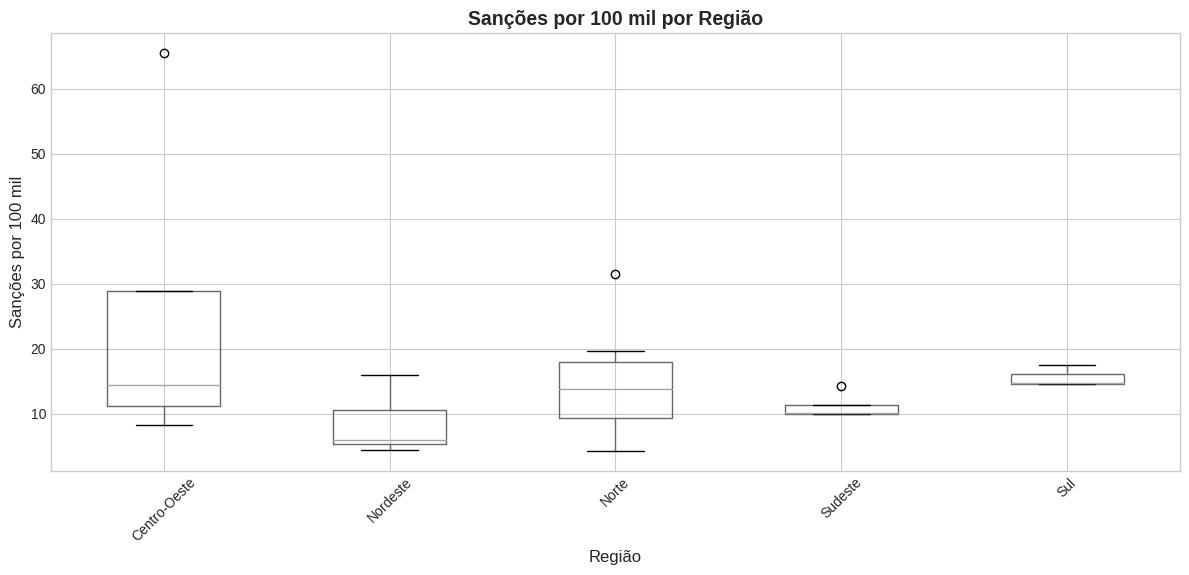

In [10]:
plt.figure(figsize=(12, 6))
df.boxplot(column='sanctions_per_100k', by='region_name', ax=plt.gca())
plt.title('Sanções por 100 mil por Região', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Região', fontsize=12)
plt.ylabel('Sanções por 100 mil', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3.2 Testes Post-hoc (Tukey HSD)

Teste Post-hoc Tukey HSD
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1     group2  meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
Centro-Oeste Nordeste -17.2575 0.1184  -37.442   2.927  False
Centro-Oeste    Norte -10.7536 0.5638 -31.8066 10.2995  False
Centro-Oeste  Sudeste -14.5126 0.3916 -38.2636  9.2385  False
Centro-Oeste      Sul -10.1092 0.7683 -35.7632 15.5449  False
    Nordeste    Norte   6.5039 0.7839 -10.4234 23.4312  False
    Nordeste  Sudeste   2.7449  0.994 -17.4396 22.9294  False
    Nordeste      Sul   7.1483 0.8752 -15.2444  29.541  False
       Norte  Sudeste   -3.759 0.9833  -24.812  17.294  False
       Norte      Sul   0.6444    1.0 -22.5342  23.823  False
     Sudeste      Sul   4.4034 0.9856 -21.2506 30.0574  False
-------------------------------------------------------------


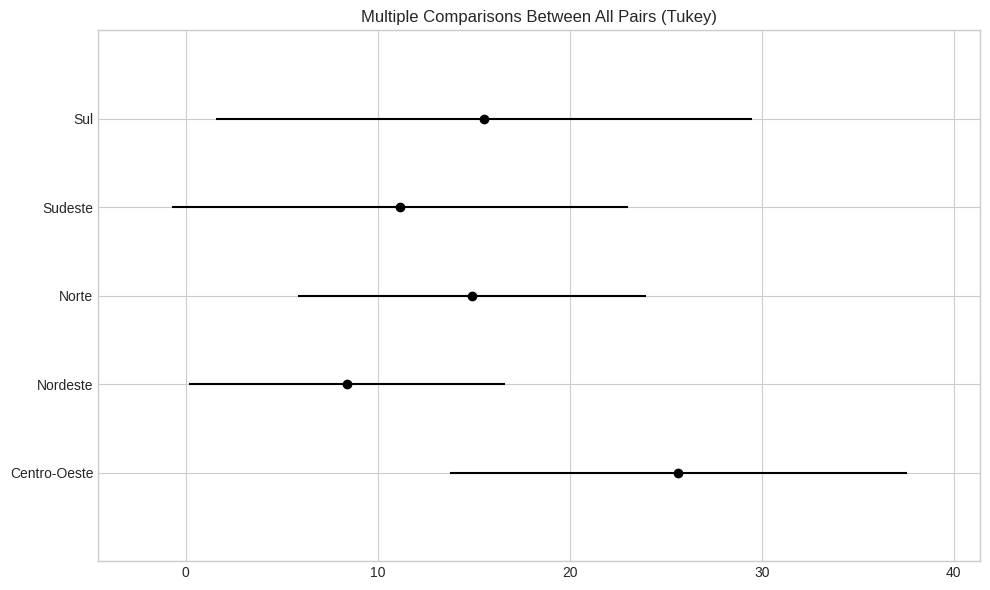

In [11]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['sanctions_per_100k'], 
                          groups=df['region_name'], 
                          alpha=0.05)

print("Teste Post-hoc Tukey HSD")
print("=" * 80)
print(tukey)

tukey.plot_simultaneous()
plt.tight_layout()
plt.show()


## 4. Regressão Linear Múltipla

### 4.1 Especificação do Modelo

In [12]:
y = df['sanctions_per_100k']

X_vars = ['log_income', 'avg_literacy_rate', 'log_population', 
          'is_norte', 'is_nordeste', 'is_sul', 'is_centro_oeste']

# Converter para float para evitar problemas de tipo com statsmodels
X = df[X_vars].copy().astype(float)
X = sm.add_constant(X)

print("Especificação do Modelo:")
print("=" * 70)
print(f"Variável Dependente: sanctions_per_100k")
print(f"Variáveis Independentes: {X_vars}")
print(f"\nTamanho da amostra: {len(X)}")
print(f"Número de preditores: {len(X_vars)}")


Especificação do Modelo:
Variável Dependente: sanctions_per_100k
Variáveis Independentes: ['log_income', 'avg_literacy_rate', 'log_population', 'is_norte', 'is_nordeste', 'is_sul', 'is_centro_oeste']

Tamanho da amostra: 27
Número de preditores: 7


### 4.2 Regressão MQO (Mínimos Quadrados Ordinários)

In [13]:
model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     sanctions_per_100k   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     13.78
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           3.05e-06
Time:                        19:22:20   Log-Likelihood:                -80.340
No. Observations:                  27   AIC:                             176.7
Df Residuals:                      19   BIC:                             187.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -296.3712     57.40

### 4.3 Interpretação dos Coeficientes

In [14]:
coef_df = pd.DataFrame({
    'Variável': model.params.index,
    'Coeficiente': model.params.values,
    'Erro Padrão': model.bse.values,
    'Estatística-t': model.tvalues.values,
    'Valor-p': model.pvalues.values,
    'IC Inferior': model.conf_int()[0].values,
    'IC Superior': model.conf_int()[1].values
})

coef_df['Significativo'] = coef_df['Valor-p'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
)

print("\nCoeficientes de Regressão")
print("=" * 100)
display(coef_df.round(4))



Coeficientes de Regressão


,Variável,Coeficiente,Erro Padrão,Estatística-t,Valor-p,IC Inferior,IC Superior,Significativo
0,const,-296.3712,57.4081,-5.1625,0.0001,-416.5278,-176.2146,***
1,log_income,49.7466,9.0338,5.5067,0.0000,30.8387,68.6545,***
2,avg_literacy_rate,0.0116,0.7462,0.0155,0.9878,-1.5502,1.5733,ns
3,log_population,-3.1550,1.7410,-1.8122,0.0858,-6.7989,0.4889,ns
4,is_norte,20.9427,6.2252,3.3642,0.0033,7.9134,33.9721,**
5,is_nordeste,22.9706,7.9125,2.9031,0.0091,6.4096,39.5317,**
6,is_sul,-9.7164,4.6427,-2.0928,0.0500,-19.4337,0.0010,ns
7,is_centro_oeste,-2.0310,4.8139,-0.4219,0.6778,-12.1065,8.0446,ns


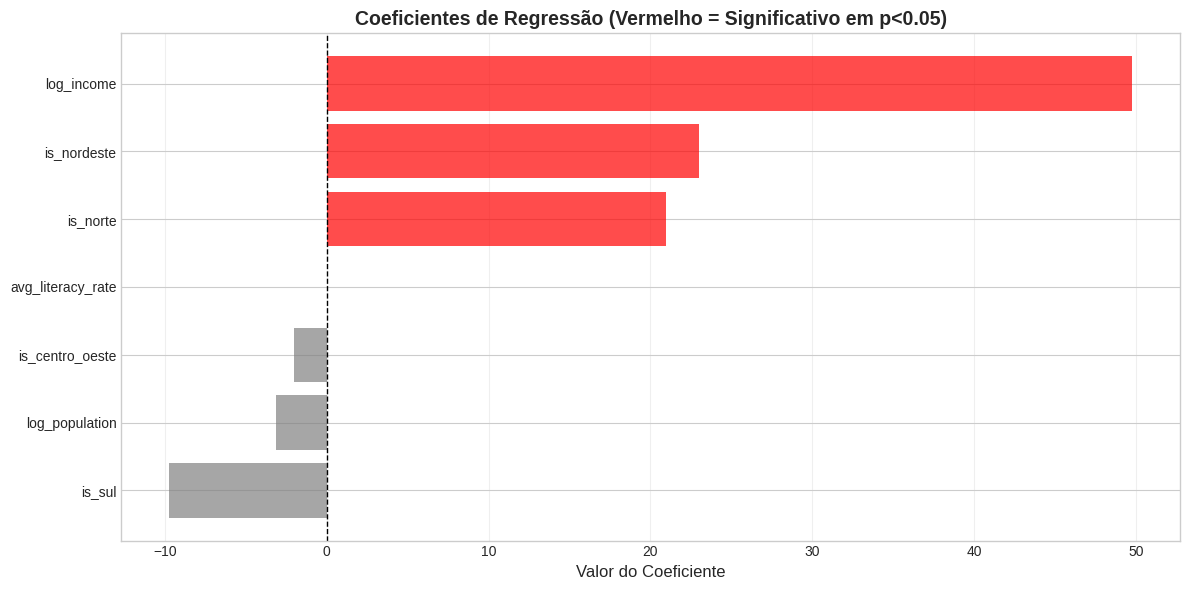

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

coef_plot = coef_df[coef_df['Variável'] != 'const'].copy()
coef_plot = coef_plot.sort_values('Coeficiente')

colors = ['red' if p < 0.05 else 'gray' for p in coef_plot['Valor-p']]

ax.barh(coef_plot['Variável'], coef_plot['Coeficiente'], color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Valor do Coeficiente', fontsize=12)
ax.set_title('Coeficientes de Regressão (Vermelho = Significativo em p<0.05)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


## 5. Diagnósticos do Modelo

### 5.1 Análise de Resíduos

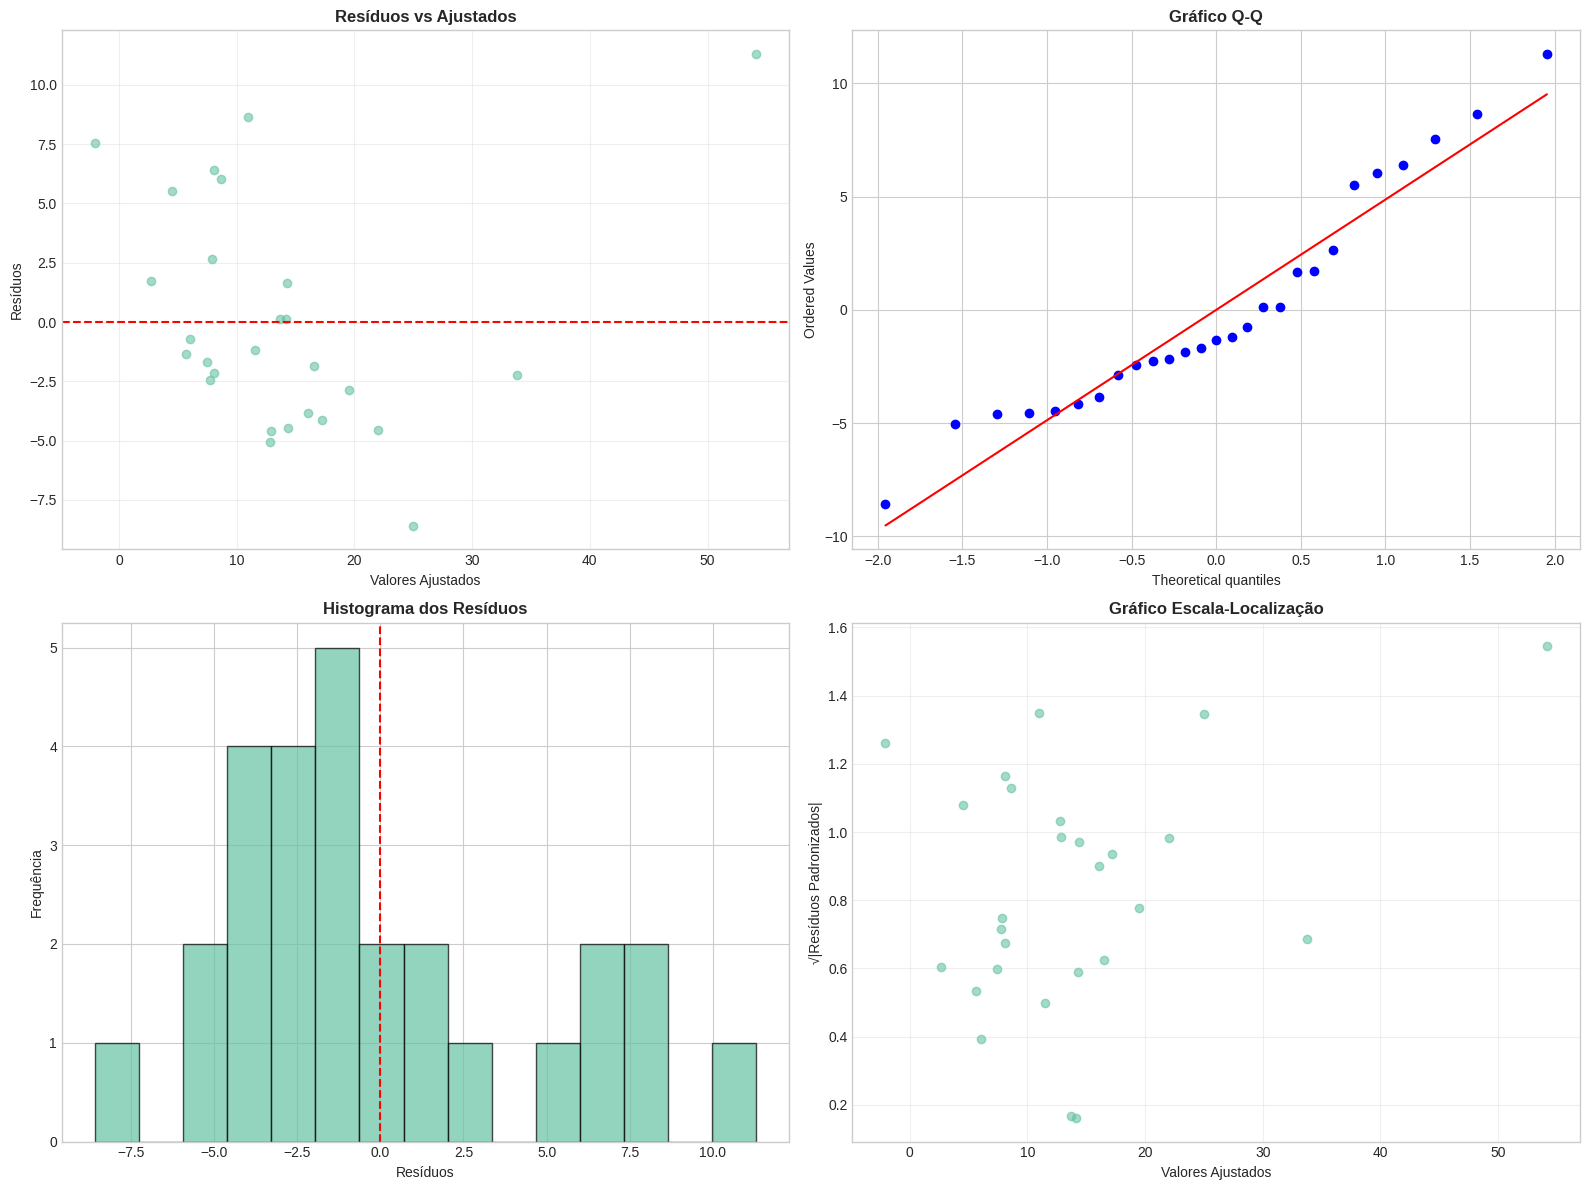

In [16]:
residuals = model.resid
fitted = model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].scatter(fitted, residuals, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Valores Ajustados')
axes[0, 0].set_ylabel('Resíduos')
axes[0, 0].set_title('Resíduos vs Ajustados', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Gráfico Q-Q', fontweight='bold')

axes[1, 0].hist(residuals, bins=15, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Resíduos')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].set_title('Histograma dos Resíduos', fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--')

standardized_resid = residuals / np.std(residuals)
axes[1, 1].scatter(fitted, np.sqrt(np.abs(standardized_resid)), alpha=0.6)
axes[1, 1].set_xlabel('Valores Ajustados')
axes[1, 1].set_ylabel('√|Resíduos Padronizados|')
axes[1, 1].set_title('Gráfico Escala-Localização', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 5.2 Testes de Normalidade

In [17]:
shapiro_stat, shapiro_p = shapiro(residuals)
jb_stat, jb_p = jarque_bera(residuals)

print("Testes de Normalidade dos Resíduos")
print("=" * 70)
print(f"Shapiro-Wilk Test:")
print(f"  Estatística: {shapiro_stat:.4f}")
print(f"  P-value: {shapiro_p:.4f}")
print(f"  Resultado: {'Rejeitar normalidade' if shapiro_p < 0.05 else 'Não pode rejeitar normalidade'}\n")

print(f"Jarque-Bera Test:")
print(f"  Estatística: {jb_stat:.4f}")
print(f"  P-value: {jb_p:.4f}")
print(f"  Resultado: {'Rejeitar normalidade' if jb_p < 0.05 else 'Não pode rejeitar normalidade'}")


Testes de Normalidade dos Resíduos
Shapiro-Wilk Test:
  Estatística: 0.9354
  P-value: 0.0936
  Resultado: Não pode rejeitar normalidade

Jarque-Bera Test:
  Estatística: 2.1553
  P-value: 0.3404
  Resultado: Não pode rejeitar normalidade


### 5.3 Testes de Heterocedasticidade

In [18]:
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X)

print("Testes de Heterocedasticidade")
print("=" * 70)
print(f"Breusch-Pagan Test:")
print(f"  Estatística: {bp_stat:.4f}")
print(f"  P-value: {bp_p:.4f}")
print(f"  Resultado: {'Heterocedasticidade detectada' if bp_p < 0.05 else 'Homocedasticidade (variância constante)'}")


Testes de Heterocedasticidade
Breusch-Pagan Test:
  Estatística: 8.3923
  P-value: 0.2993
  Resultado: Homocedasticidade (variância constante)


### 5.4 Multicolinearidade (VIF)

In [19]:
X_no_const = X.drop('const', axis=1)

vif_data = pd.DataFrame()
vif_data['Variável'] = X_no_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_no_const.values, i) 
                   for i in range(X_no_const.shape[1])]

vif_data['Multicolinearidade'] = vif_data['VIF'].apply(
    lambda x: 'Alto (>10)' if x > 10 else 'Moderado (5-10)' if x > 5 else 'Baixo (<5)'
)

print("Análise do Fator de Inflação da Variância (VIF)")
print("=" * 70)
print("Regra geral: VIF > 10 indica alta multicolinearidade\n")
display(vif_data.sort_values('VIF', ascending=False))


Análise do Fator de Inflação da Variância (VIF)
Regra geral: VIF > 10 indica alta multicolinearidade



,Variável,VIF,Multicolinearidade
1,avg_literacy_rate,3412.2430,Alto (>10)
0,log_income,2672.5161,Alto (>10)
2,log_population,485.9812,Alto (>10)
4,is_nordeste,8.8052,Moderado (5-10)
3,is_norte,3.6843,Baixo (<5)
6,is_centro_oeste,2.8933,Baixo (<5)
5,is_sul,1.9589,Baixo (<5)


### 5.5 Observações Influentes

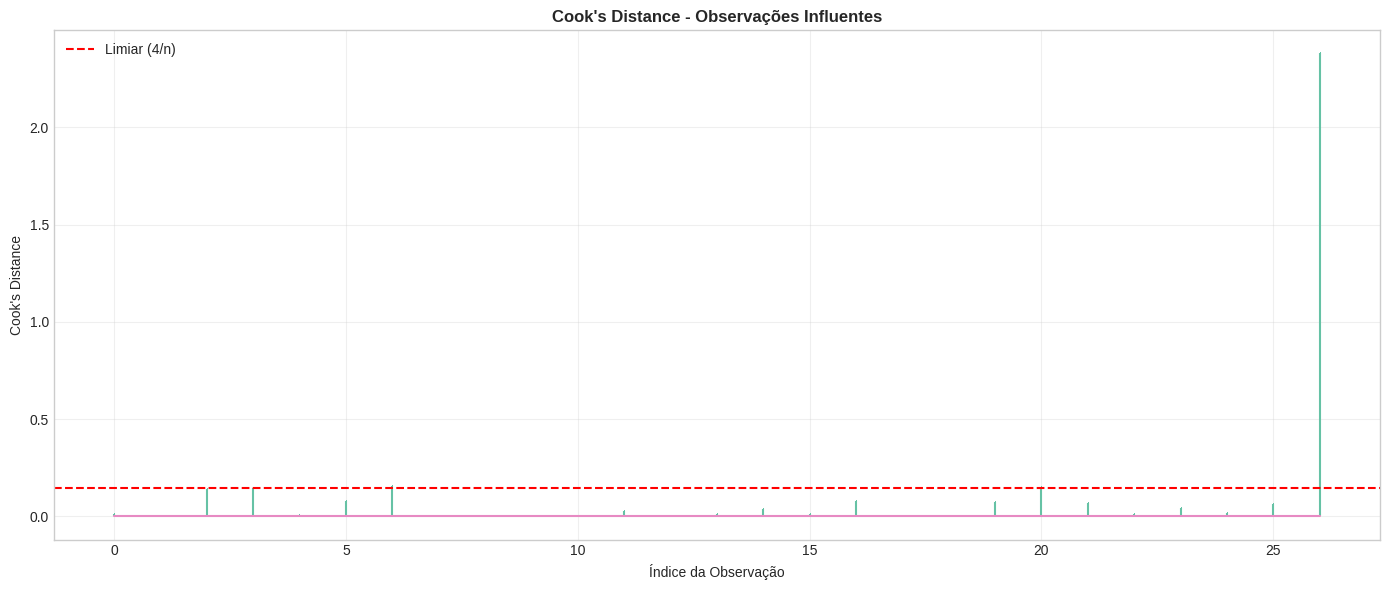


Observações influentes (D de Cook > 0.1481):
          state_name  sanctions_per_100k
6          Tocantins             16.4080
20            Paraná             14.5224
26  Distrito Federal             65.4509


In [20]:
from statsmodels.stats.outliers_influence import OLSInfluence

influence = OLSInfluence(model)
cooks_d = influence.cooks_distance[0]

fig, ax = plt.subplots(figsize=(14, 6))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=',')
ax.axhline(y=4/len(X), color='r', linestyle='--', label='Limiar (4/n)')
ax.set_xlabel('Índice da Observação')
ax.set_ylabel("Cook's Distance")
ax.set_title("Cook's Distance - Observações Influentes", fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

threshold = 4 / len(X)
influential = df[cooks_d > threshold][['state_name', 'sanctions_per_100k']]
if len(influential) > 0:
    print(f"\nObservações influentes (D de Cook > {threshold:.4f}):")
    print(influential)
else:
    print("\nNenhuma observação altamente influente detectada.")


## 6. Comparação de Modelos

In [21]:
X_simple = sm.add_constant(df[['log_income', 'avg_literacy_rate']])
model_simple = sm.OLS(y, X_simple).fit()

X_full = X.copy()
model_full = model

comparison = pd.DataFrame({
    'Model': ['Simples (2 vars)', 'Completo (7 vars + regiões)'],
    'R-squared': [model_simple.rsquared, model_full.rsquared],
    'Adj. R-squared': [model_simple.rsquared_adj, model_full.rsquared_adj],
    'AIC': [model_simple.aic, model_full.aic],
    'BIC': [model_simple.bic, model_full.bic],
    'F-statistic': [model_simple.fvalue, model_full.fvalue],
    'Prob (F)': [model_simple.f_pvalue, model_full.f_pvalue]
})

print("Comparação de Modelos")
print("=" * 80)
display(comparison.round(4))

print("\nNota: Menor AIC/BIC indica melhor ajuste do modelo")


Comparação de Modelos


,Model,R-squared,Adj. R-squared,AIC,BIC,F-statistic,Prob (F)
0,Simples (2 vars),0.4168,0.3682,200.8405,204.7280,8.5754,0.0015
1,Completo (7 vars + regiões),0.8354,0.7748,176.6792,187.0459,13.7790,0.0000



Nota: Menor AIC/BIC indica melhor ajuste do modelo


## 7. Resumo das Descobertas

### 7.1 Análise de Correlação
- **Renda média** é o preditor mais forte de sanções por 100 mil (r = 0,74, p < 0,001).
- **Renda log-transformada** também apresenta correlação forte (r = 0,63).
- **Taxa de alfabetização** tem associação positiva moderada (r = 0,47).
- Tamanho da população e número de municípios mostram associações negativas fracas.

### 7.2 Diferenças Regionais
- **ANOVA one-way** não encontrou diferenças estatisticamente significativas entre regiões (F = 1,70; p = 0,186).
- **Tukey HSD** confirma que nenhuma comparação regional par a par é significativa em α = 0,05.
- Centro-Oeste tem a maior média (25,66), mas também a maior variância (dp = 26,74), influenciada pelo outlier do Distrito Federal.

### 7.3 Resultados da Regressão
- **Regressão OLS** alcança R² = 0,835 (R² Ajustado = 0,775), explicando a maior parte da variância nas taxas de sanções.
- **Log da renda** é o preditor significativo mais forte (β = 49,75; p < 0,001): um aumento de 1% na renda média está associado a ~0,50 sanções adicionais por 100 mil.
- **Dummies regionais** (Norte: β = 20,94, p = 0,003; Nordeste: β = 22,97, p = 0,009) são significativas, indicando que, controlando pela renda, essas regiões têm taxas de sanções acima do esperado.
- **Taxa de alfabetização** não é significativa quando a renda já está no modelo (p = 0,988), sugerindo que sua correlação bivariada é mediada pela renda.

### 7.4 Diagnósticos do Modelo
- **Normalidade**: Shapiro-Wilk (p = 0,094) e Jarque-Bera (p = 0,340) — resíduos são aproximadamente normais.
- **Homocedasticidade**: teste de Breusch-Pagan (p = 0,299) — sem evidência de heterocedasticidade.
- **Observações influentes**: Distrito Federal (D de Cook > limiar) é o ponto mais influente, junto com Tocantins e Paraná.

### 7.5 Limitações
- Amostra pequena (n = 27 estados) limita o poder estatístico e o número de preditores.
- Desenho transversal não permite estabelecer causalidade — renda mais alta pode correlacionar com maior capacidade institucional de detectar e registrar sanções, não com mais irregularidades de fato.
- O Distrito Federal é um outlier estrutural (capital federal com governança única) que influencia fortemente os resultados.
